## 🔹 Import Libraries

In [1]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\hp\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 🔹 Load Dataset

In [3]:
df = pd.read_csv('../data/train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### 🔹 Basic Info

In [4]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### 🔹 Check Missing Values

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing.head(10)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
dtype: int64

### 🔹 Target Variable (VERY IMPORTANT)

In [6]:
df['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

## First Visualization

### 🔹 Price Distribution

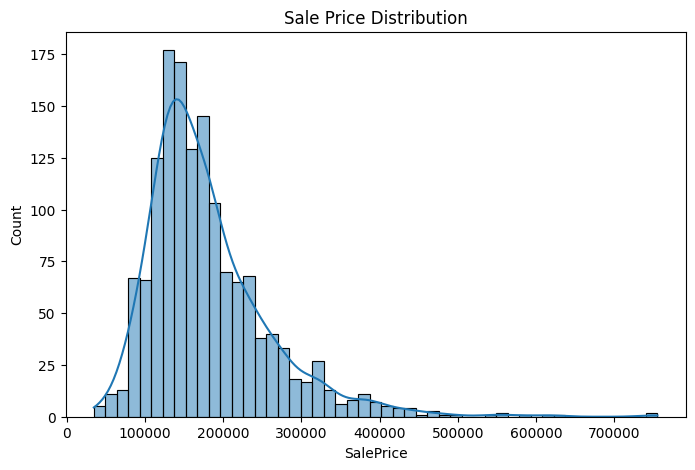

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['SalePrice'], kde=True)
plt.title("Sale Price Distribution")
plt.show()

### 🔹 Correlation with Target

In [8]:
corr = df.corr(numeric_only=True)
top_corr = corr['SalePrice'].sort_values(ascending=False)
top_corr.head(10)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

### Check Missing Values (Again)

In [9]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing.head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

### Handle Missing Values (SMART WAY)

#### 🔹 1. Drop Columns with Too Many Missing Values

In [10]:
df = df.drop(columns=['PoolQC', 'MiscFeature', 'Alley', 'Fence'])

#### 🔹 2. Fill Numerical Columns

In [11]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

#### 🔹 3. Fill Categorical Columns

In [12]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

### Encode Categorical Variables

In [13]:
df = pd.get_dummies(df, drop_first=True)

### Final Check

In [14]:
df.isnull().sum().sum()

np.int64(0)

### Save Clean Dataset

In [15]:
df.to_csv('../data/cleaned_data.csv', index=False)

In [16]:
df.shape

(1460, 237)

In [17]:
df = pd.read_csv('../data/cleaned_data.csv')

### Correlation Heatmap (KEY VISUAL)

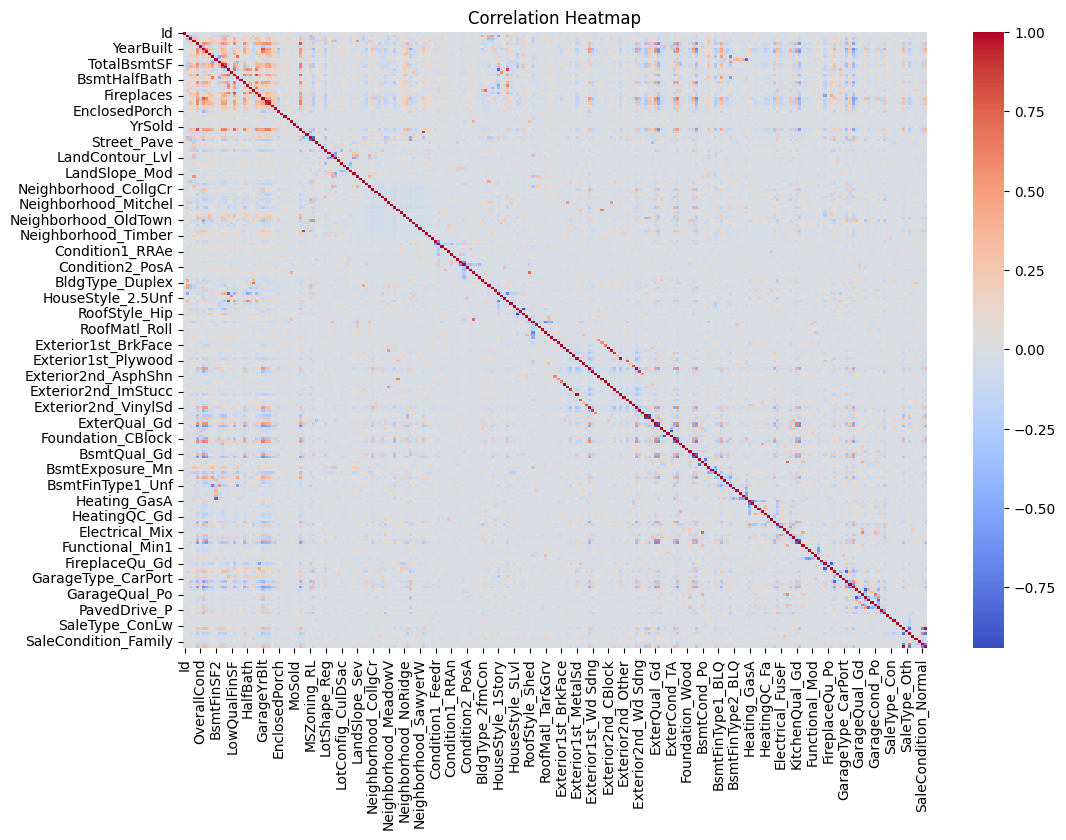

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
corr = df.corr()

sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Top Features Correlated with Price

In [19]:
corr = df.corr()

top_corr = corr['SalePrice'].sort_values(ascending=False)

top_corr.head(10)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

### Plot Top Correlations

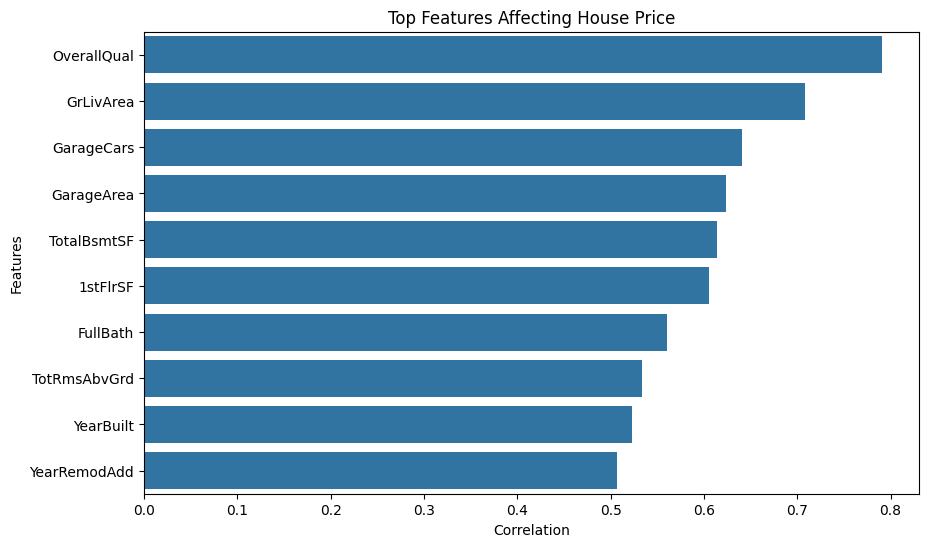

In [20]:
top_features = top_corr.index[1:11]

plt.figure(figsize=(10,6))
sns.barplot(x=top_corr[1:11].values, y=top_features)
plt.title("Top Features Affecting House Price")
plt.xlabel("Correlation")
plt.ylabel("Features")
plt.show()

### Important Scatter Plots

#### 🔹 Example 1:

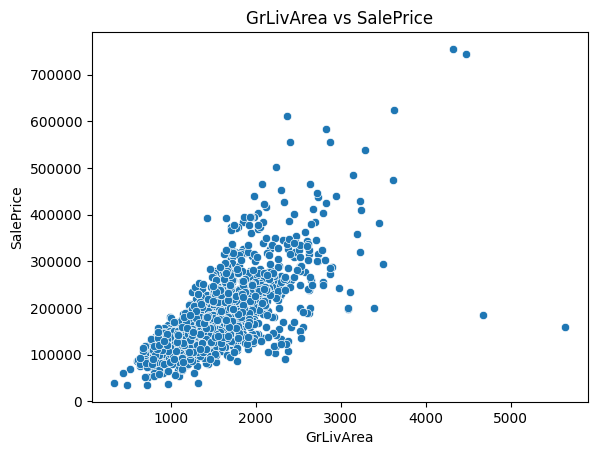

In [21]:
sns.scatterplot(x=df['GrLivArea'], y=df['SalePrice'])
plt.title("GrLivArea vs SalePrice")
plt.show()

#### 🔹 Example 2:

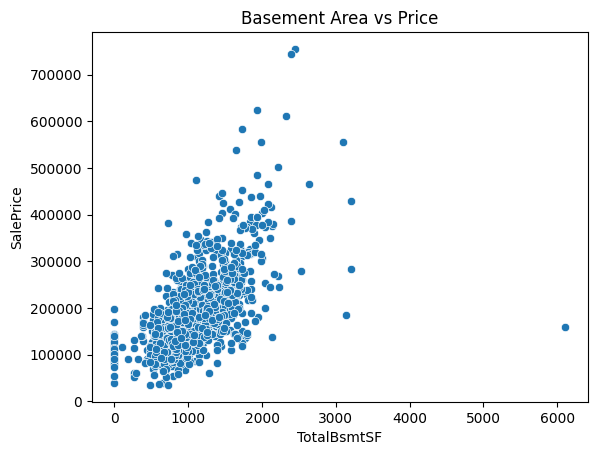

In [22]:
sns.scatterplot(x=df['TotalBsmtSF'], y=df['SalePrice'])
plt.title("Basement Area vs Price")
plt.show()

### Save Images (IMPORTANT FOR GITHUB)

In [23]:
plt.figure(figsize=(10,6))
sns.barplot(x=top_corr[1:11].values, y=top_features)
plt.title("Top Features Affecting House Price")

plt.savefig('../images/top_features.png')
plt.close()

✍️ Example:


OverallQual has the highest correlation with SalePrice


GrLivArea strongly affects house prices

Some features have very low impact

Data shows positive linear relationships

# 🗓️ ✅ DAY 5 — Feature Engineering (VERY IMPORTANT)

🎯 Goal Today:

✔ Create new meaningful features

✔ Improve model performance

✔ Prepare data for training

✔ Save updated dataset

✔ Push to GitHub

## 🧠 Why Feature Engineering Matters

👉 Models don’t think — they learn from features

👉 Better features = better predictions

### 📓 STEP 1 — Load Clean Data

In [24]:
df = pd.read_csv('../data/cleaned_data.csv')

### 🔧 STEP 2 — Create New Features

#### 🔹 1. Total Square Feet

In [25]:
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

#### 🔹 2. Total Bathrooms

In [26]:
df['TotalBathrooms'] = (
    df['FullBath'] +
    (0.5 * df['HalfBath']) +
    df['BsmtFullBath'] +
    (0.5 * df['BsmtHalfBath'])
)

#### 🔹 3. House Age

In [27]:
df['HouseAge'] = df['YrSold'] - df['YearBuilt']

#### 🔹 4. Remodel Age (Optional but GOOD)

In [28]:
df['RemodelAge'] = df['YrSold'] - df['YearRemodAdd']

### 🧪 STEP 3 — Check New Features

In [29]:
df[['TotalSF', 'TotalBathrooms', 'HouseAge']].head()

,TotalSF,TotalBathrooms,HouseAge
0,2566,3.5,5
1,2524,2.5,31
2,2706,3.5,7
3,2473,2.0,91
4,3343,3.5,8


### 📊 STEP 4 — Check Correlation with Target

In [30]:
corr = df.corr(numeric_only=True)
corr['SalePrice'].sort_values(ascending=False).head(10)

SalePrice         1.000000
OverallQual       0.790982
TotalSF           0.782260
GrLivArea         0.708624
GarageCars        0.640409
TotalBathrooms    0.631731
GarageArea        0.623431
TotalBsmtSF       0.613581
1stFlrSF          0.605852
FullBath          0.560664
Name: SalePrice, dtype: float64

### 💾 STEP 5 — Save Updated Dataset

In [31]:
df.to_csv('../data/processed_data.csv', index=False)

## 🗓️ ✅ DAY 6 — Linear Regression (First Model)

🎯 Goal Today:

✔ Train your first ML model

✔ Make predictions

✔ Evaluate performance (MAE, RMSE)

✔ Visualize results

✔ Push to GitHub

### 📓 STEP 1 — Load Processed Data

In [33]:
import pandas as pd

df = pd.read_csv('../data/processed_data.csv')

### 🧠 STEP 2 — Define Features & Target

In [34]:
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

### 🔀 STEP 3 — Train-Test Split

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 🤖 STEP 4 — Train Linear Regression Model

In [36]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### 🔮 STEP 5 — Make Predictions

In [38]:
y_pred = lr.predict(X_test)

### 📊 STEP 6 — Evaluate Model

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 20436.780806456314
RMSE: 52315.52434720367


### 📈 STEP 7 — Plot Actual vs Predicted

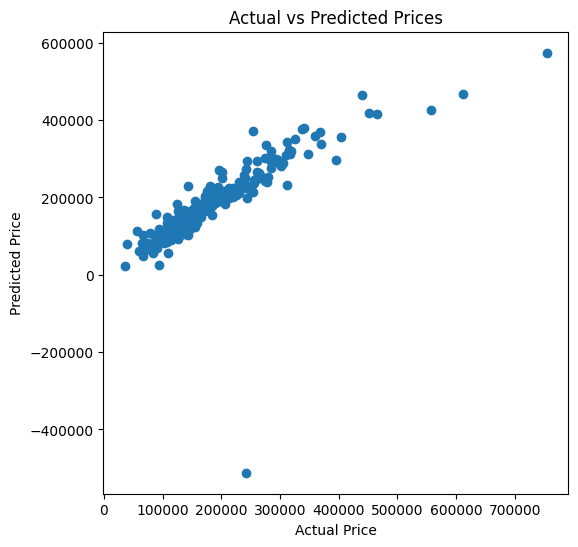

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

### 💾 STEP 8 —Save Model

In [41]:
import joblib
joblib.dump(lr, '../models/linear_regression.pkl')

['../models/linear_regression.pkl']